# Breast Cancer Differential Gene Expression and Pathway Analysis

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "/content/brca_clean_expression_dataset.csv",
    index_col=0
)

df.head()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,patient_id,label
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169,3.579965,4.996181,5.614683,4.385652,5.843705,...,0.537346,0.0,0.000000,0.0,3.533999,0.0,0.058109,1.122739,TCGA-D8-A146,1
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989,2.322361,4.943860,6.539078,4.046404,5.711726,...,0.204767,0.0,0.000000,0.0,4.773448,0.0,0.054779,1.243182,TCGA-AQ-A0Y5,1
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248,2.124130,2.993348,5.119912,3.409907,5.963742,...,0.412402,0.0,0.000000,0.0,4.701710,0.0,0.093425,0.604261,TCGA-C8-A274,1
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790,3.122375,4.754674,5.608738,3.625691,5.678199,...,0.268075,0.0,0.966357,0.0,4.689075,0.0,0.059771,0.536351,TCGA-BH-A0BD,1
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548,1.508581,3.722149,5.224044,3.242221,5.956145,...,0.434028,0.0,0.000000,0.0,5.168221,0.0,0.023752,0.389126,TCGA-B6-A1KC,1


## Data Loading and Initial Exploration

In [4]:
df['label'].value_counts()

,count
label,
1,1106
0,113


In [5]:
gene_cols = [
    col for col in df.columns
    if str(col).startswith("ENSG")
]

len(gene_cols)

60660

In [6]:
tumor = df[df['label'] == 1]
normal = df[df['label'] == 0]

In [7]:
print(tumor.shape)
print(normal.shape)

(1106, 60662)
(113, 60662)


## Gene Filtering

Compute Mean Expression

In [10]:
from scipy.stats import ttest_ind

In [15]:
from statsmodels.stats.multitest import multipletests

In [20]:
tumor[gene_cols].iloc[:5, :5]

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17
TCGA-D8-A146-01A,5.662037,3.376096,6.860140,4.400552,2.845169
TCGA-AQ-A0Y5-01A,3.703721,0.463099,7.086452,4.051007,2.426989
TCGA-C8-A274-01A,6.514515,0.000000,6.805072,5.037264,4.043248
TCGA-BH-A0BD-01A,4.784917,2.328061,6.443071,4.374970,4.162790
TCGA-B6-A1KC-01B,4.251984,0.435415,6.178436,3.558464,2.589548


In [31]:
df['label'].value_counts()


,count
label,
1,1106
0,113


In [32]:
tumor = df[df['label'] == 1]
normal = df[df['label'] == 0]

print(tumor.shape)
print(normal.shape)

(1106, 60662)
(113, 60662)


In [33]:
gene = gene_cols[0]

print(tumor[gene].head())
print(normal[gene].head())

TCGA-D8-A146-01A    2.735963
TCGA-AQ-A0Y5-01A    2.233802
TCGA-C8-A274-01A    2.909680
TCGA-BH-A0BD-01A    2.532296
TCGA-B6-A1KC-01B    2.392863
Name: ENSG00000000003.15, dtype: float64
TCGA-BH-A18L-11A    2.784373
TCGA-BH-A1FE-11B    2.929960
TCGA-BH-A209-11A    2.818360
TCGA-BH-A1F6-11B    2.824627
TCGA-E9-A1N6-11A    2.768878
Name: ENSG00000000003.15, dtype: float64


In [34]:
deg_results['p_value'].isna().sum()

np.int64(2613)

In [36]:
df = df.dropna(axis=1)

In [37]:
gene_cols = [
    col for col in df.columns
    if str(col).startswith("ENSG")
]

In [38]:
mean_expression = df[gene_cols].mean()

In [39]:
filtered_genes = mean_expression[
    mean_expression > 1
].index

In [40]:
gene_cols = list(filtered_genes)

In [41]:
len(gene_cols)

16845

In [42]:
variance = df[gene_cols].var()

gene_cols = variance[
    variance > 0.01
].index.tolist()

In [43]:
len(gene_cols)

16594

In [44]:
tumor = df[df['label'] == 1]
normal = df[df['label'] == 0]

## Differential Expression Analysis

In [45]:
tumor_mean = tumor[gene_cols].mean()
normal_mean = normal[gene_cols].mean()

log2_fc = tumor_mean - normal_mean

In [46]:
from scipy.stats import ttest_ind

p_values = []

for gene in gene_cols:

    _, p = ttest_ind(
        tumor[gene],
        normal[gene],
        equal_var=False
    )

    p_values.append(p)

In [47]:
deg_results = pd.DataFrame({
    'gene': gene_cols,
    'log2FoldChange': log2_fc.values,
    'p_value': p_values
})

In [48]:
deg_results = deg_results.dropna()

In [49]:
deg_results.isna().sum()

,0
gene,0
log2FoldChange,0
p_value,0


In [50]:
from statsmodels.stats.multitest import multipletests

deg_results['adj_p_value'] = multipletests(
    deg_results['p_value'],
    method='fdr_bh'
)[1]

In [51]:
deg_results['significant'] = (
    (deg_results['adj_p_value'] < 0.05) &
    (abs(deg_results['log2FoldChange']) > 0.5)
)

In [52]:
deg_results['significant'].value_counts()

,count
significant,
False,15206
True,1388


In [53]:
deg_results.to_csv(
    "differential_expression_results.csv",
    index=False
)

#graphs

## Volcano Plot Visualization

In [54]:
deg_results['neg_log10_p'] = -np.log10(
    deg_results['adj_p_value']
)

In [55]:
significant = deg_results[
    deg_results['significant'] == True
]

non_significant = deg_results[
    deg_results['significant'] == False
]

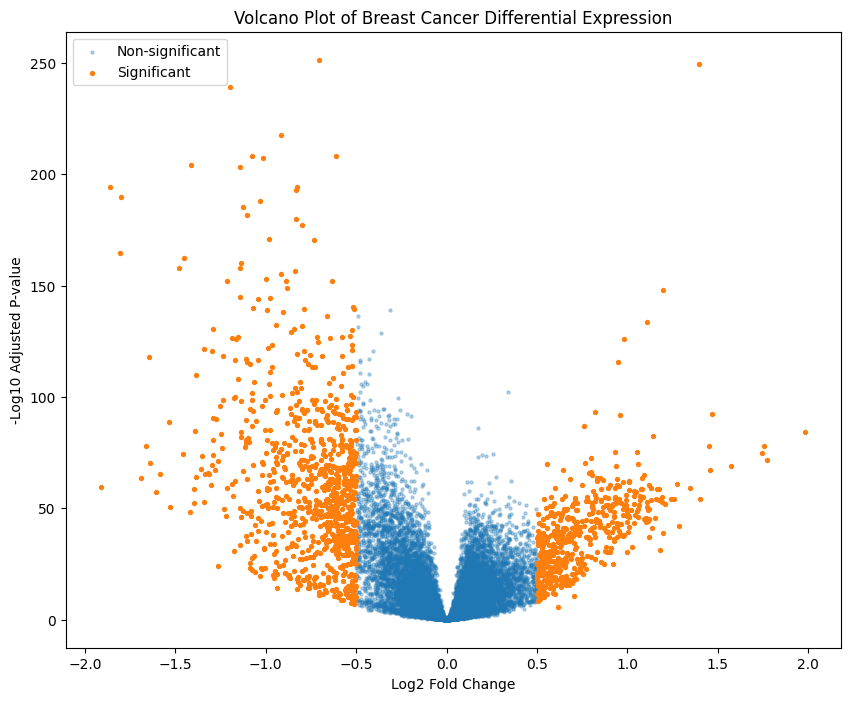

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    non_significant['log2FoldChange'],
    non_significant['neg_log10_p'],
    s=5,
    alpha=0.3,
    label='Non-significant'
)

plt.scatter(
    significant['log2FoldChange'],
    significant['neg_log10_p'],
    s=8,
    label='Significant'
)

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot of Breast Cancer Differential Expression")

plt.legend()

plt.show()

## Top Up/Down Regulated Genes

Top upregulated genes

In [57]:
top_upregulated = deg_results.sort_values(
    by='log2FoldChange',
    ascending=False
).head(20)

top_upregulated

,gene,log2FoldChange,p_value,adj_p_value,significant,neg_log10_p
4350,ENSG00000123500.10,1.984988,1.187861e-86,7.821973e-85,True,84.106684
13876,ENSG00000230838.1,1.772605,3.190369e-74,1.347099e-72,True,71.870600
9754,ENSG00000170373.8,1.756540,3.254175e-80,1.703463e-78,True,77.768667
5963,ENSG00000137745.12,1.747512,2.711170e-77,1.281742e-75,True,74.892199
680,ENSG00000060718.22,1.574145,2.403586e-71,9.003411e-70,True,69.045593
12664,ENSG00000203805.11,1.466237,3.567012e-95,3.325337e-93,True,92.478164
12073,ENSG00000196611.5,1.454890,1.297006e-69,4.437634e-68,True,67.352849
1776,ENSG00000099953.10,1.450752,2.409309e-80,1.273251e-78,True,77.895086
3863,ENSG00000117650.13,1.400459,2.853956e-56,5.782484e-55,True,54.237886
396,ENSG00000029559.7,1.396651,3.397839e-254,2.819187e-250,True,249.549876


Top downregulated genes

In [58]:
top_downregulated = deg_results.sort_values(
    by='log2FoldChange'
).head(20)

top_downregulated

,gene,log2FoldChange,p_value,adj_p_value,significant,neg_log10_p
10332,ENSG00000174697.5,-1.912265,8.669166e-62,2.153535e-60,True,59.666848
8241,ENSG00000161649.13,-1.862321,5.416953e-198,8.988892e-195,True,194.046294
9415,ENSG00000168079.17,-1.806395,2.346589e-168,1.854252e-165,True,164.731831
8899,ENSG00000165197.5,-1.798954,1.157997e-193,1.478139e-190,True,189.830285
11408,ENSG00000184811.4,-1.692883,1.168772e-65,3.469516e-64,True,63.459731
8909,ENSG00000165269.13,-1.660406,2.381004e-80,1.262312e-78,True,77.898833
12074,ENSG00000196616.14,-1.644074,8.363228e-121,1.802330e-118,True,117.744166
11734,ENSG00000187288.12,-1.641296,9.182586e-73,3.689488e-71,True,70.433034
10518,ENSG00000176194.18,-1.604637,1.507842e-59,3.441695e-58,True,57.463228
11013,ENSG00000181092.10,-1.584532,8.029390e-68,2.582165e-66,True,65.588016


In [59]:
significant.to_csv(
    "significant_genes.csv",
    index=False
)

Pathway Enrichment Analysis

In [60]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 15.7 MB/s eta 0:00:00


In [61]:
import pandas as pd
import gseapy as gp

In [62]:
deg_results = pd.read_csv(
    "/content/differential_expression_results.csv"
)

deg_results.head()

,gene,log2FoldChange,p_value,adj_p_value,significant
0,ENSG00000000003.15,-0.209977,2.224665e-30,1.393060e-29,False
1,ENSG00000000419.13,0.064880,9.823974e-17,3.066573e-16,False
2,ENSG00000000457.14,0.087255,1.040647e-05,1.702672e-05,False
3,ENSG00000000460.17,0.386280,5.143429e-34,3.791651e-33,False
4,ENSG00000000938.13,-0.151067,4.038569e-08,7.782604e-08,False


In [63]:
significant_genes = deg_results[
    deg_results['significant'] == True
]

In [64]:
significant_genes['gene_clean'] = (
    significant_genes['gene']
    .str.split('.')
    .str[0]
)

/tmp/ipykernel_11040/1565248512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_genes['gene_clean'] = (


In [65]:
!pip install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.7 MB/s eta 0:00:00


In [66]:
import mygene

In [67]:
mg = mygene.MyGeneInfo()

In [68]:
gene_info = mg.querymany(
    significant_genes['gene_clean'].tolist(),
    scopes='ensembl.gene',
    fields='symbol',
    species='human'
)

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-1388 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [69]:
gene_symbols = []

for item in gene_info:

    if 'symbol' in item:
        gene_symbols.append(item['symbol'])

In [70]:
gene_symbols[:20]

['KLHL13',
 'CYP26B1',
 'DBNDD1',
 'TFPI',
 'HSPB6',
 'PDK4',
 'ZMYND10',
 'PRSS22',
 'MEOX1',
 'THSD7A',
 'ACSM3',
 'TMEM132A',
 'CX3CL1',
 'PROM1',
 'SLC13A2',
 'E2F2',
 'CELSR3',
 'AASS',
 'MAPK8IP2',
 'MLXIPL']

In [72]:
enrichment_results = gp.enrichr(
    gene_list=gene_symbols,
    gene_sets='KEGG_2021_Human',
    organism='human',
    outdir='kegg_results'
)

In [73]:
results = enrichment_results.results

results.head()


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Cell cycle,27/124,2.938661e-08,0.000008,0,0,4.000454,69.378789,CDKN1C;BUB1B;TTK;PKMYT1;CDC14B;CDC20;CCNB2;CCN...
1,KEGG_2021_Human,Alcoholism,30/186,4.782728e-06,0.000682,0,0,2.761479,33.829495,MAOB;MAOA;GNAI1;ADCY5;H2AC11;H2AC13;GNG2;H3C10...
2,KEGG_2021_Human,Cytokine-cytokine receptor interaction,40/295,1.169749e-05,0.001111,0,0,2.257966,25.641765,CX3CR1;CNTFR;CCL13;IL20;CCL11;CXCL1;CXCL13;CXC...
3,KEGG_2021_Human,PPAR signaling pathway,16/74,2.074299e-05,0.001478,0,0,3.939497,42.480782,MMP1;ADIPOQ;AQP7;LPL;SORBS1;FABP4;FABP7;PLIN4;...
4,KEGG_2021_Human,Regulation of lipolysis in adipocytes,13/55,4.538088e-05,0.002587,0,0,4.413852,44.140374,NPR1;PDE3B;PTGER3;ADCY4;AQP7;IRS2;ADRB2;PTGS2;...


In [74]:
top_pathways = results.sort_values(
    by='Adjusted P-value'
).head(10)

top_pathways

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Cell cycle,27/124,2.938661e-08,0.000008,0,0,4.000454,69.378789,CDKN1C;BUB1B;TTK;PKMYT1;CDC14B;CDC20;CCNB2;CCN...
1,KEGG_2021_Human,Alcoholism,30/186,4.782728e-06,0.000682,0,0,2.761479,33.829495,MAOB;MAOA;GNAI1;ADCY5;H2AC11;H2AC13;GNG2;H3C10...
2,KEGG_2021_Human,Cytokine-cytokine receptor interaction,40/295,1.169749e-05,0.001111,0,0,2.257966,25.641765,CX3CR1;CNTFR;CCL13;IL20;CCL11;CXCL1;CXCL13;CXC...
3,KEGG_2021_Human,PPAR signaling pathway,16/74,2.074299e-05,0.001478,0,0,3.939497,42.480782,MMP1;ADIPOQ;AQP7;LPL;SORBS1;FABP4;FABP7;PLIN4;...
4,KEGG_2021_Human,Regulation of lipolysis in adipocytes,13/55,4.538088e-05,0.002587,0,0,4.413852,44.140374,NPR1;PDE3B;PTGER3;ADCY4;AQP7;IRS2;ADRB2;PTGS2;...
5,KEGG_2021_Human,Systemic lupus erythematosus,22/135,7.244318e-05,0.003441,0,0,2.784911,26.547741,H4C8;H2BC9;H2AC8;H2BC7;H2BC8;H2BC5;H2BC6;H2BC4...
6,KEGG_2021_Human,Viral protein interaction with cytokine and cy...,18/100,8.675378e-05,0.003532,0,0,3.135551,29.325045,CX3CR1;CCL13;IL20;CCL11;CCL21;IL34;CXCL1;CXCL1...
7,KEGG_2021_Human,Viral carcinogenesis,27/203,3.993320e-04,0.013551,0,0,2.195423,17.180759,HPN;CDC20;CHEK1;CCR8;H4C4;CCR4;H4C5;H4C8;H2BC9...
8,KEGG_2021_Human,Tyrosine metabolism,9/36,4.279246e-04,0.013551,0,0,4.742690,36.786976,AOC3;IL4I1;AOC2;ADH1C;MAOB;ADH1B;MAOA;TAT;AOX1
9,KEGG_2021_Human,Phenylalanine metabolism,6/17,5.370339e-04,0.015305,0,0,7.749689,58.350888,AOC3;IL4I1;AOC2;MAOB;MAOA;TAT


<Axes: title={'center': 'Top KEGG Pathways'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

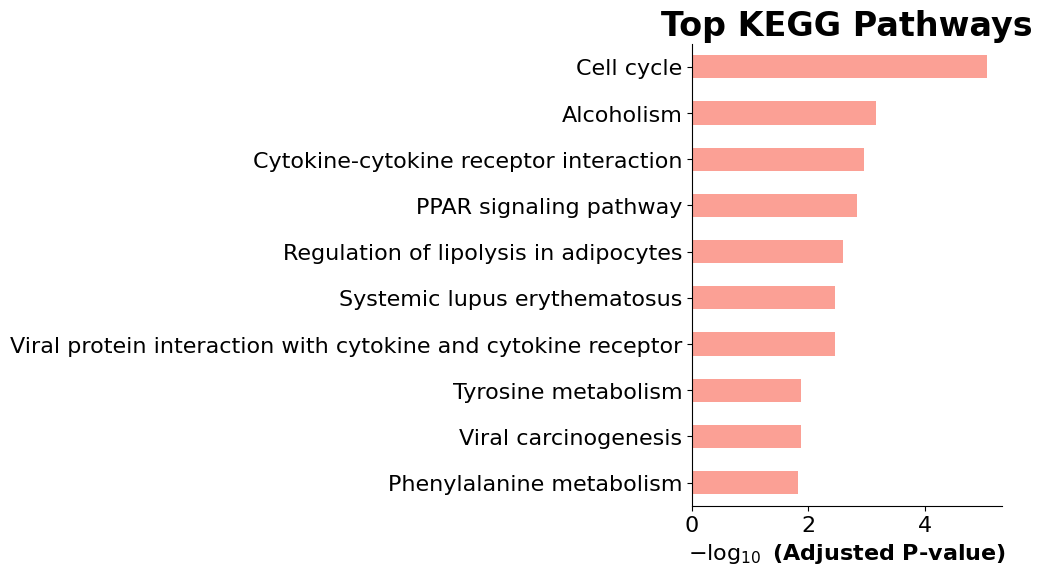

In [78]:
gp.barplot(
    df=results,
    title='Top KEGG Pathways',
    cutoff=0.05
)


<Axes: title={'center': 'Top Enriched KEGG Pathways'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

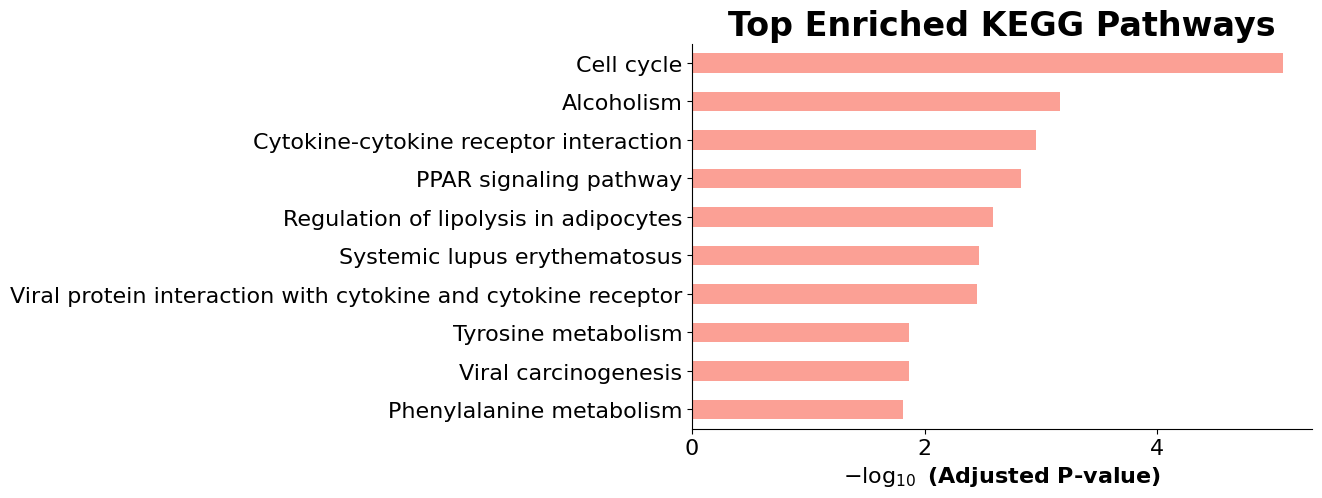

In [82]:
gp.barplot(
    df=top_pathways,
    title='Top Enriched KEGG Pathways',
    figsize=(8,5),
    cutoff=0.05
)

## Download Pathway Visualization

In [79]:
import matplotlib.pyplot as plt

plt.savefig(
    "kegg_pathway_barplot.png",
    dpi=300,
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>